# 1D spectral analysis of a point-like gamma-ray source

This notebook introduces a one-dimensional spectral analysis workflow with Gammapy. We use a set of public DL3 observations, define an ON region around a target source, estimate the background with the reflected-regions method, fit a spectral model, and compute flux points.

The goal is to provide a compact hands-on example of the main steps involved in a high-level gamma-ray analysis:

- loading DL3 observations;
- defining the target region and energy axes;
- creating reduced ON/OFF spectral datasets;
- fitting a spectral model;
- estimating flux points.

In [1]:
import logging
from copy import deepcopy

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import Angle, SkyCoord
from regions import CircleSkyRegion
from scipy.stats import chi2

from gammapy.data import DataStore
from gammapy.datasets import Datasets, SpectrumDataset
from gammapy.estimators import FluxPointsEstimator
from gammapy.makers import (
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker,
)
from gammapy.maps import MapAxis, RegionGeom, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    ExpCutoffPowerLawSpectralModel,
    LogParabolaSpectralModel,
    Models,
    PowerLawSpectralModel,
    SkyModel,
)
from gammapy.stats.utils import ts_to_sigma
from gammapy.visualization import plot_spectrum_datasets_off_regions

import warnings

logging.basicConfig()
log = logging.getLogger("gammapy-tutorial")
log.setLevel(logging.INFO)

## Accessing Crab Nebula observations

We start by loading the public H.E.S.S. DL3 DR1 dataset distributed with the Gammapy datasets.

DL3 data contain event lists and instrument response functions for individual observations. In this example, we select the observations whose pointing positions are close to the Crab Nebula and retrieve them from the `DataStore`.

In [2]:
# Load the public H.E.S.S. DL3 DR1 data
data_store = DataStore.from_dir("$GAMMAPY_DATA/hess-dl3-dr1")

# Crab Nebula position in ICRS coordinates
crab_position = SkyCoord(ra=83.633083 * u.deg, dec=22.0145 * u.deg, frame="icrs")

# Resolve the Crab Nebula coordinates by name.
# This requires an internet connection.
crab_position = SkyCoord.from_name("Crab")

# Select observations with pointing positions within 2 deg of the Crab Nebula
obs_table = data_store.obs_table.select_sky_circle(
    center=crab_position,
    radius=2 * u.deg,
)

obs_ids = obs_table["OBS_ID"]
observations = data_store.get_observations(obs_ids)

print(f"Selected observation IDs: {list(obs_ids)}")
print(f"Number of selected observations: {len(observations)}")

INFO:gammapy.data.data_store:Observations selected: 4 out of 4.


Selected observation IDs: [23523, 23526, 23559, 23592]
Number of selected observations: 4


**Note.** The selection above is based on the observation pointing positions, not on the size of the ON region used for the spectral extraction.

Here we selected all observations whose pointing position lies within 2 deg of the Crab Nebula. This is a practical way to retrieve the relevant runs, including wobble observations, where the source is offset from the camera center.

The actual ON region used to extract the source spectrum will be defined later and will be much smaller. For this point-source example, we will use an ON radius of 0.1 deg.

In [3]:
# Inspect the selected observation table
obs_table

OBS_ID,RA_PNT,DEC_PNT,GLON_PNT,GLAT_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,OBJECT,RA_OBJ,DEC_OBJ,OFFSET_OBJ,ONTIME,LIVETIME,DEADC,TSTART,TSTOP,DATE-OBS,TIME-OBS,DATE-END,TIME-END,N_TELS,TELLIST,QUALITY,MUONEFF,EVENT_COUNT,TARGET_NAME,TARGET_TAG,TARGET_OFFSET,SAFE_ENERGY_LO,SAFE_ENERGY_HI
,deg,deg,deg,deg,deg,deg,deg,,deg,deg,deg,s,s,,s,s,,,,,,,,,,,,deg,TeV,TeV
int64,float32,float32,float32,float32,float32,float32,float32,bytes18,float32,float32,float32,float32,float32,float32,float64,float64,bytes10,bytes12,bytes10,bytes12,int64,bytes7,int64,float32,int64,bytes21,bytes14,float32,float32,float32
23523,83.63333,21.514444,184.9823,-6.0516925,48.61021,41.38979,22.481705,Crab Nebula,83.63333,22.014444,0.5,1687.0,1581.7368,0.9376033,123890826.0,123892513.0,2004-12-04,22:08:10.184,2004-12-04,22:36:17.184,4,"1,2,3,4",0,0.9070748,7613,Crab,crab,0.500049,0.8709636,100.0
23526,83.63333,22.514444,184.13332,-5.5163794,45.77929,44.22071,8.542603,Crab Nebula,83.63333,22.014444,0.5,1683.0,1572.6868,0.9344544,123893580.0,123895263.0,2004-12-04,22:54:04.184,2004-12-04,23:22:07.184,4,"1,2,3,4",0,0.9142412,7581,Crab,crab,0.49995112,0.70794576,100.0
23559,85.253334,22.014444,185.35727,-4.510869,45.368176,44.631824,2.2535799,Crab Nebula,83.63333,22.014444,1.5018803,1686.0,1578.1235,0.9360163,124067051.0,124068737.0,2004-12-06,23:05:15.184,2004-12-06,23:33:21.184,4,"1,2,3,4",0,0.91964024,7601,Crab,crab,1.5021166,0.66069347,100.0
23592,82.013336,22.014444,183.7408,-7.047852,48.389248,41.610752,21.7556,Crab Nebula,83.63333,22.014444,1.5018733,1686.0,1581.2646,0.9378794,124235636.0,124237322.0,2004-12-08,21:55:00.184,2004-12-08,22:23:06.184,4,"1,2,3,4",0,0.9120389,7334,Crab,crab,1.5016365,0.8709636,100.0


For more advanced observation selections, Gammapy also provides the `ObservationTable.select_observations()` method.

This allows filtering observations using different criteria, such as sky position, observation time, or parameter ranges. For example, one could select observations within a given zenith-angle range or time interval.

## Inspecting one representative observation and its IRFs

Before building the reduced spectral datasets, it is useful to inspect one observation in more detail.

Gammapy provides convenient `peek()` methods for quick diagnostic plots:

- `events.peek()` shows basic event distributions, such as energy and offset;
- `aeff.peek()` shows the effective area;
- `edisp.peek()` shows the energy dispersion;
- `psf.peek()` shows the point-spread function;
- `bkg.peek()` shows the background model, when available in the DL3 data.

Here we simply use the first selected observation as a representative run for visual inspection before moving to the full dataset reduction.

In [4]:
# Use the first selected observation as a representative example
obs_0 = observations[0]

print(f"Representative observation ID: {obs_0.obs_id}")
print(type(obs_0))

Representative observation ID: 23523
<class 'gammapy.data.observations.Observation'>


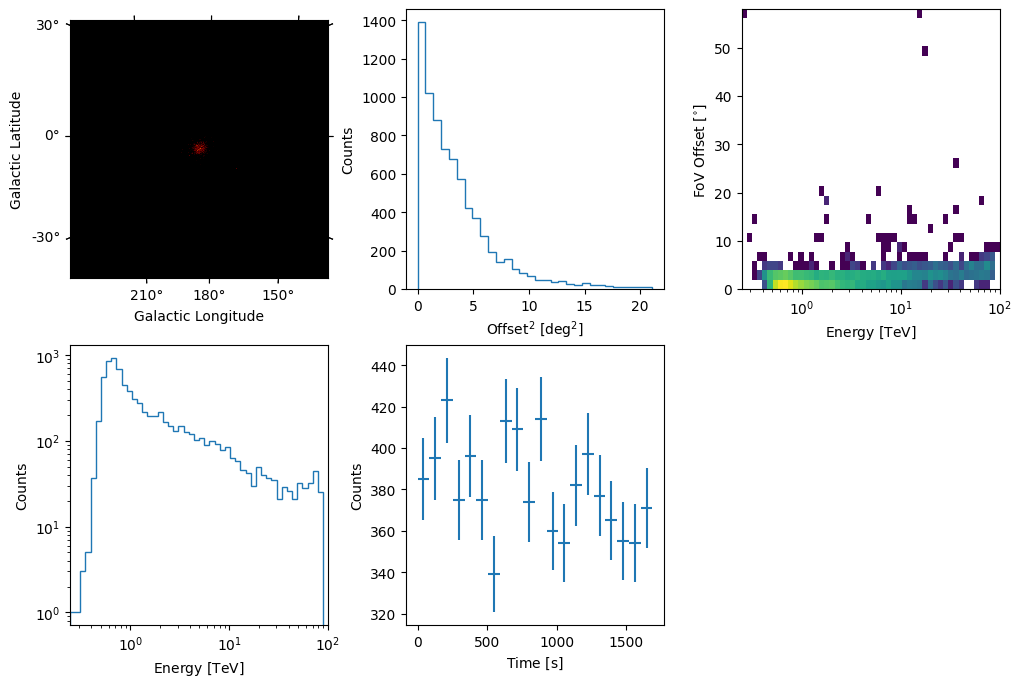

In [5]:
# Inspect the event distribution for the representative observation
obs_0.events.peek()

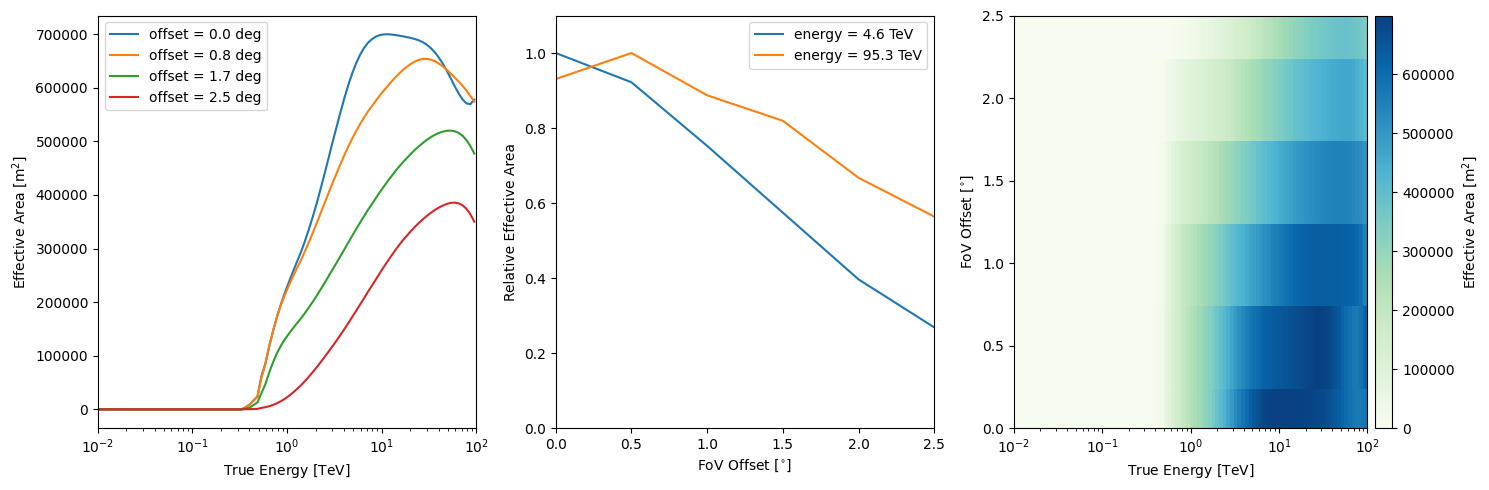

In [6]:
# Inspect the effective area
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="invalid value encountered in divide",
        category=RuntimeWarning,
    )
    obs_0.aeff.peek()

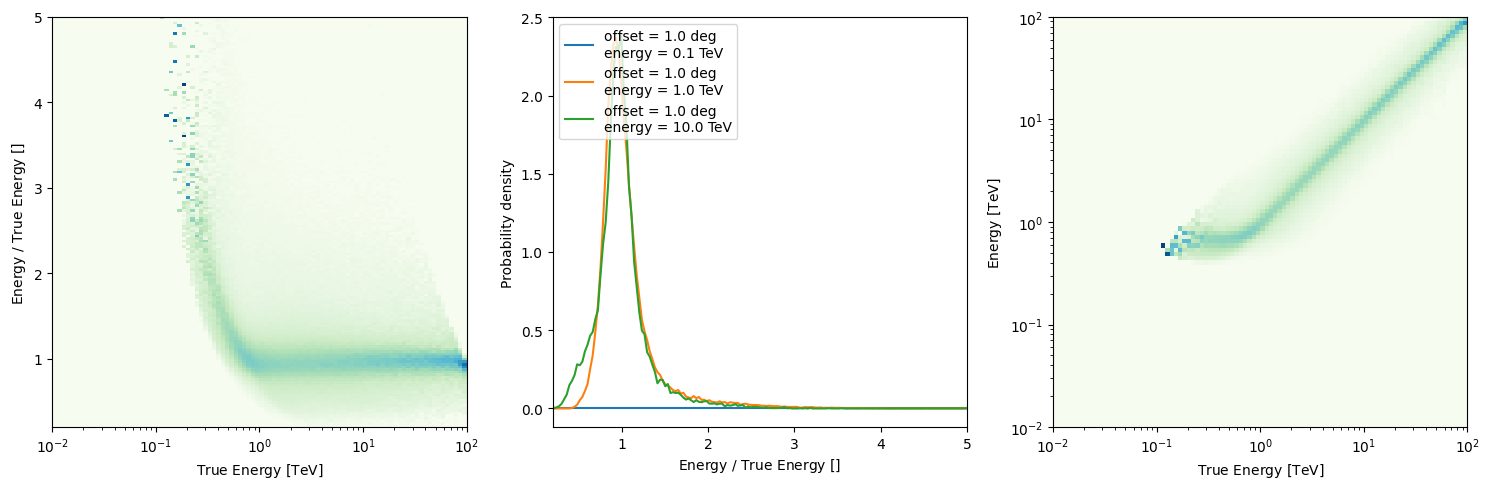

In [7]:
# Inspect the energy dispersion (EDISP)
obs_0.edisp.peek()


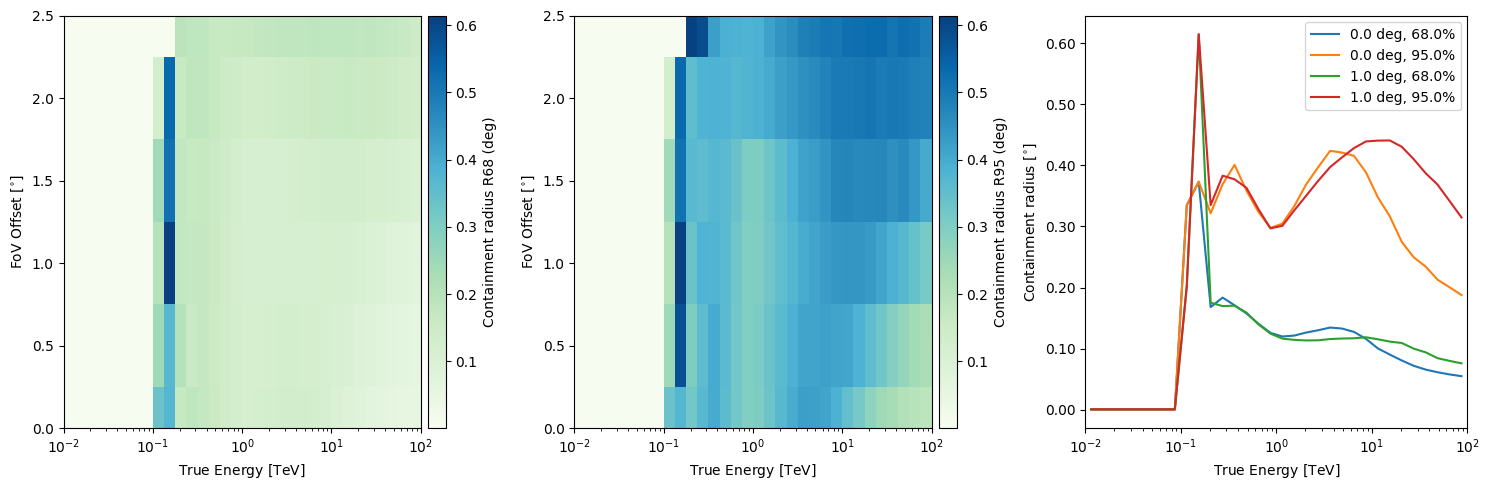

In [8]:
# Inspect the Point Spread Function (PSF)
obs_0.psf.peek()


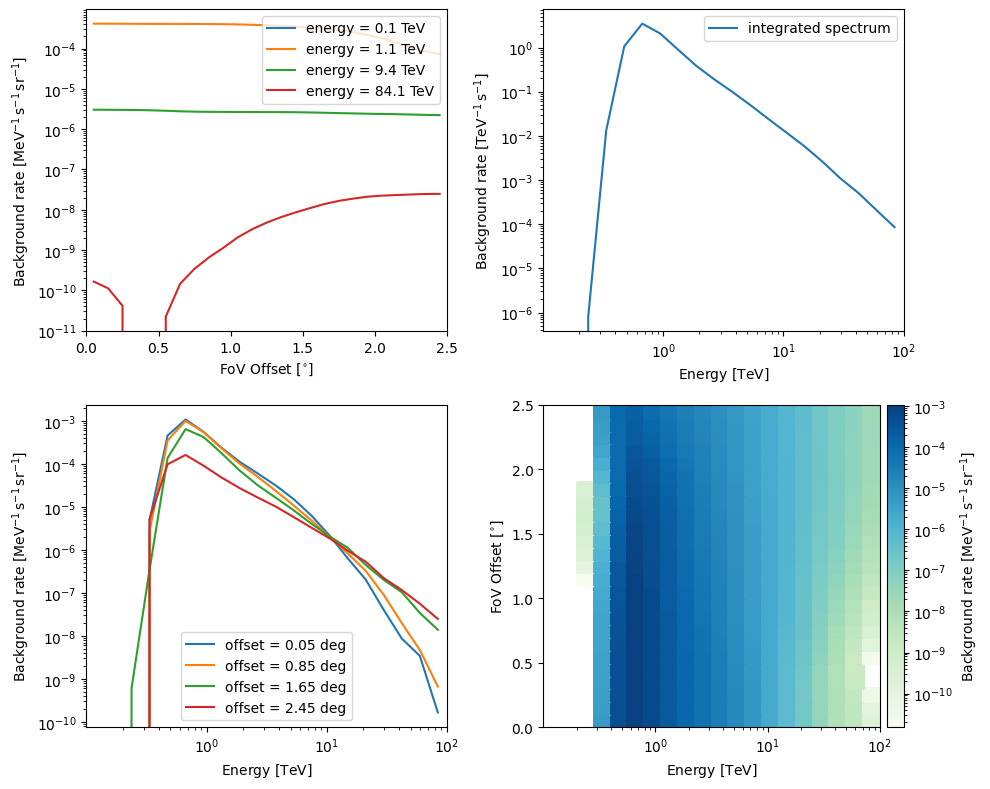

In [9]:
# Inspect the background model if it is available in the DL3 data
if getattr(obs_0, "bkg", None) is not None:
    obs_0.bkg.peek()
else:
    print("No background model is available for this observation.")

## Preparing the reduced dataset geometry

We now define the energy axes used to build the one-dimensional spectral datasets.

In Gammapy, it is useful to distinguish between:

- **reconstructed energy**: the estimated energy assigned to each detected event;
- **true energy**: the simulated or physical photon energy used to evaluate instrument response functions, such as the effective area and energy dispersion.

The reconstructed-energy axis defines the bins of the final measured spectrum, while the true-energy axis is used internally for exposure and energy-dispersion calculations.

In [10]:
# Reconstructed-energy axis: bins used for the measured spectrum
energy_axis = MapAxis.from_energy_bounds(
    0.1, 40, nbin=10, per_decade=True, unit="TeV", name="energy"
)

# True-energy axis: used to evaluate IRFs and model predictions
# It is usually wider and more finely binned than the reconstructed-energy axis.
energy_axis_true = MapAxis.from_energy_bounds(
    0.05, 100, nbin=20, per_decade=True, unit="TeV", name="energy_true"
)

energy_axis, energy_axis_true

(MapAxis
 
 	name       : energy    
 	unit       : 'TeV'     
 	nbins      : 27        
 	node type  : edges     
 	edges min  : 1.0e-01 TeV
 	edges max  : 4.0e+01 TeV
 	interp     : log       ,
 MapAxis
 
 	name       : energy_true
 	unit       : 'TeV'     
 	nbins      : 67        
 	node type  : edges     
 	edges min  : 5.0e-02 TeV
 	edges max  : 1.0e+02 TeV
 	interp     : log       )

### Defining the ON region and analysis geometry

We define a circular ON region centered on the Crab Nebula. This region is used to extract the source counts for the one-dimensional spectral analysis.

Here we use a radius of **0.11 deg**, a common choice for point-source examples with this public H.E.S.S. dataset. The optimal radius depends on the instrument response, event selection, source morphology, and analysis choices.

We then create a `RegionGeom` object by combining the sky region with the reconstructed-energy axis.

In [11]:
# Define the circular ON region centered on the Crab Nebula
on_region_radius = Angle("0.11 deg")
on_region = CircleSkyRegion(center=crab_position, radius=on_region_radius)

# Create the region-based geometry for the spectral extraction
geom = RegionGeom.create(region=on_region, axes=[energy_axis])

geom

## Creating an empty spectral dataset

We now create an empty `SpectrumDataset` that defines the target geometry and true-energy axis for the analysis.

This object acts as a template. In the next step, the dataset makers will fill it with counts, exposure, energy dispersion, and background information for each observation.

In [12]:
# Create an empty dataset with the analysis geometry
dataset_empty = SpectrumDataset.create(
    geom=geom,
    energy_axis_true=energy_axis_true,
)

print(dataset_empty)

SpectrumDataset
---------------

  Name                            : S2HokQuL 

  Total counts                    : 0 
  Total background counts         : 0.00
  Total excess counts             : 0.00

  Predicted counts                : 0.00
  Predicted background counts     : 0.00
  Predicted excess counts         : nan

  Exposure min                    : 0.00e+00 m2 s
  Exposure max                    : 0.00e+00 m2 s

  Number of total bins            : 27 
  Number of fit bins              : 0 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : nan

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0




## Optional: creating an exclusion mask for OFF regions

The reflected-regions background method places OFF regions at the same offset from the pointing position as the ON region. In fields with multiple gamma-ray sources, some reflected regions may overlap with regions that should not be used to estimate the background.

An exclusion mask can be used to prevent OFF regions from being placed on top of known sources or other regions that should be excluded from the background estimation.

For the Crab Nebula field used here, this step is not strictly necessary. We include it as an optional example because exclusion masks are commonly needed in more crowded fields.

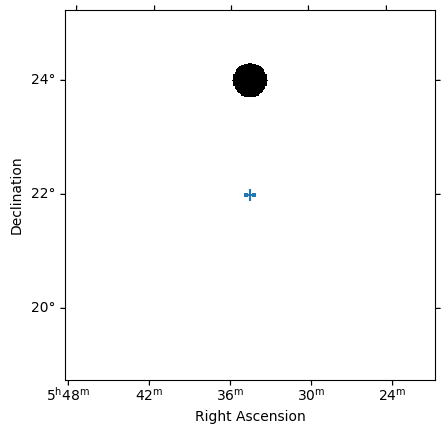

In [13]:
# Build a WCS geometry around the Crab Nebula
exclusion_geom = WcsGeom.create(
    skydir=crab_position.icrs,
    width=6.5 * u.deg,
    binsz=0.02,
    proj="TAN",
    frame="icrs",
)

# Define an example exclusion region.
# In a real analysis, this would correspond to a known nearby source
# or to another region that should not be used for background estimation.
exclusion_center = SkyCoord(
    ra=crab_position.ra,
    dec=crab_position.dec + 2 * u.deg,
    frame="icrs",
)
exclusion_region = CircleSkyRegion(
    center=exclusion_center,
    radius=0.3 * u.deg,
)

# The region mask is True inside the selected region.
# For an exclusion mask, False marks the excluded pixels.
region_mask = exclusion_geom.region_mask([exclusion_region])
exclusion_mask = ~region_mask

ax = exclusion_mask.plot(add_cbar=False)

ax.scatter(
    crab_position.ra.deg,
    crab_position.dec.deg,
    s=80,
    marker="+",
    transform=ax.get_transform("icrs"),
);

## Data reduction

We now reduce the selected DL3 observations into one-dimensional ON/OFF spectral datasets.

For each observation, the reduction will:

- extract events inside the ON region;
- compute the exposure and energy dispersion for the target region;
- estimate the background using reflected OFF regions;
- apply a safe energy mask.

### Creating the maker classes

Gammapy uses maker classes to define the different steps of the data-reduction workflow. Here we initialize:

- `SpectrumDatasetMaker`, which fills the counts, exposure, and energy-dispersion information;
- `ReflectedRegionsBackgroundMaker`, which defines reflected OFF regions for background estimation;
- `SafeMaskMaker`, which applies a safe energy range based on the instrument response.

In [14]:
# Fill counts, exposure, and energy dispersion for each observation

dataset_maker = SpectrumDatasetMaker(
    containment_correction=True, 
    selection=["counts", "exposure", "edisp"],
)

**Note**: The option `containment_correction=True` accounts for the fraction of the point-source flux contained inside the finite ON region.

The `ReflectedRegionsBackgroundMaker` estimates the background using the reflected-regions method.

In this method, OFF regions are placed at the same offset from the pointing position as the ON region. These OFF regions are used to estimate the residual background from the data, assuming that the background acceptance is approximately symmetric around the pointing direction.

When applied to a `SpectrumDataset`, the reflected-regions background maker produces a `SpectrumDatasetOnOff`, which contains the ON counts, OFF counts, exposure information, and the ON/OFF acceptance ratio.

In [15]:
# Use the optional exclusion mask when placing reflected OFF regions
use_exclusion_mask = True

if use_exclusion_mask:
    bkg_maker = ReflectedRegionsBackgroundMaker(exclusion_mask=exclusion_mask)
else:
    bkg_maker = ReflectedRegionsBackgroundMaker()

The `SafeMaskMaker` defines the safe energy range of each observation.

Here we use two criteria:

- `aeff-max`: removes reconstructed-energy bins where the effective area is below 10% of its maximum value;
- `edisp-bias`: removes bins where the energy reconstruction bias is larger than 10%.

Together, these criteria avoid energy bins where the instrument response is poorly constrained or where the reconstructed energy is significantly biased.

In [16]:
# Define the safe energy range using effective-area and energy-bias criteria
safe_mask_maker = SafeMaskMaker(
    methods=["aeff-max", "edisp-bias"],
    aeff_percent=10,
    bias_percent=10,
)

### Running the data reduction

We now apply the makers to each selected observation and store the resulting `SpectrumDatasetOnOff` objects in a `Datasets` container.

In [17]:
datasets = Datasets()

for obs in observations:
    dataset = SpectrumDataset.create(
        geom=geom,
        energy_axis_true=energy_axis_true,
        name=f"obs-{obs.obs_id}",
    )

    # Apply the data-reduction makers
    dataset = dataset_maker.run(dataset, obs)
    dataset = bkg_maker.run(dataset, obs)
    dataset = safe_mask_maker.run(dataset, obs)

    datasets.append(dataset)

print(f"Built {len(datasets)} spectral datasets:")
[d.name for d in datasets]

Built 4 spectral datasets:


['obs-23523', 'obs-23526', 'obs-23559', 'obs-23592']

### Checking the reduced datasets

Before fitting a spectral model, it is useful to inspect the reduced datasets. Here we check one dataset.

In [18]:
# Inspect one reduced ON/OFF dataset
d0 = datasets[0]
print(d0)

SpectrumDatasetOnOff
--------------------

  Name                            : obs-23523 

  Total counts                    : 90 
  Total background counts         : 6.00
  Total excess counts             : 84.00

  Predicted counts                : 12.46
  Predicted background counts     : 12.46
  Predicted excess counts         : nan

  Exposure min                    : 2.89e+06 m2 s
  Exposure max                    : 8.41e+08 m2 s

  Number of total bins            : 27 
  Number of fit bins              : 16 

  Fit statistic type              : wstat
  Fit statistic value (-2 log(L)) : 259.90

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0

  Total counts_off                : 72 
  Acceptance                      : 16 
  Acceptance off                  : 192 



The reduced dataset already contains the ON counts, OFF counts, exposure, energy dispersion, and acceptance information needed for a 1D ON/OFF analysis.

At this stage, no source model has been assigned yet, so the number of models is zero and model-dependent quantities such as the predicted excess counts are not defined. We will define and fit a spectral model later.

### Visualizing ON and OFF regions

After applying the `ReflectedRegionsBackgroundMaker`, each `SpectrumDatasetOnOff` contains the ON region and a set of reflected OFF regions.

The OFF regions have the same radius as the ON region and are placed at the same offset from the pointing position. They are used to estimate the residual background from regions expected to be free of gamma-ray emission.

In the plot below:

- the black circle marks the ON region centered on the Crab Nebula;
- the colored circles show the reflected OFF regions for each observation.

This is a useful diagnostic: if OFF regions overlap with known gamma-ray emission, an exclusion mask should be used.

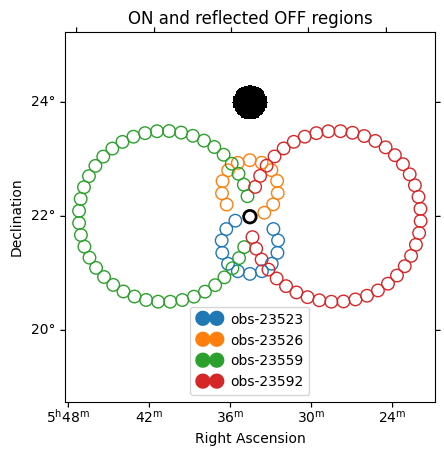

In [19]:
# Plot the exclusion mask together with the ON and reflected OFF regions
ax = exclusion_mask.plot(add_cbar=False)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="Setting the 'color' property will override*",
        category=UserWarning,
    )
    plot_spectrum_datasets_off_regions(ax=ax, datasets=datasets)

on_region.to_pixel(ax.wcs).plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=2,
)

ax.set_title("ON and reflected OFF regions");

## Spectral fitting and model comparison

We now assign spectral models to the reduced ON/OFF datasets and fit them using Gammapy.

In this section, we compare three cases:

- **H0**: no gamma-ray source model assigned to the dataset;
- **H1**: source model described by a power law;
- **H2**: source model described by a power law with an exponential cutoff.

For `SpectrumDatasetOnOff`, Gammapy uses the WStat fit stat. Since the fit statistic is defined as approximately  `-2 log L`, likelihood-ratio test statistics can be written as differences in fit statistic values:

$
TS = \mathrm{stat}_{\mathrm{null}} - \mathrm{stat}_{\mathrm{alternative}}.
$

We define two model-comparison quantities:

- **Source-model comparison**:  
  $
  TS_{\rm src} = \mathrm{stat}(H0) - \mathrm{stat}(H1)
  $

- **Cutoff comparison**:  
  $
  TS_{\rm cut} = \mathrm{stat}(H1) - \mathrm{stat}(H2)
  $

The first comparison checks how much the fit improves when a source model is added. The second comparison checks whether adding an exponential cutoff improves the fit relative to a simple power law.

Before fitting, we stack the individual `SpectrumDatasetOnOff` objects into a single dataset.

Stacking combines the information from the selected observations into one ON/OFF spectrum, which simplifies the spectral fit for this introductory example. The alternative would be a joint fit, where all per-observation datasets are fitted simultaneously.

In [20]:
stacked = datasets.stack_reduce(name="crab-stacked")

### H0: no source model

As a reference case, we first evaluate the fit statistic with no gamma-ray source model assigned to the stacked dataset.

This case should be understood as a **no-source model**, not as a dataset with no background.

In [21]:
stat_h0 = stacked.stat_sum()

print(f"stat(H0) = {stat_h0:.2f}")

stat(H0) = 1259.57


We can inspect the residuals under the no-source hypothesis. Since the Crab Nebula is a bright gamma-ray source, we expect clear positive residuals when no source model is included.

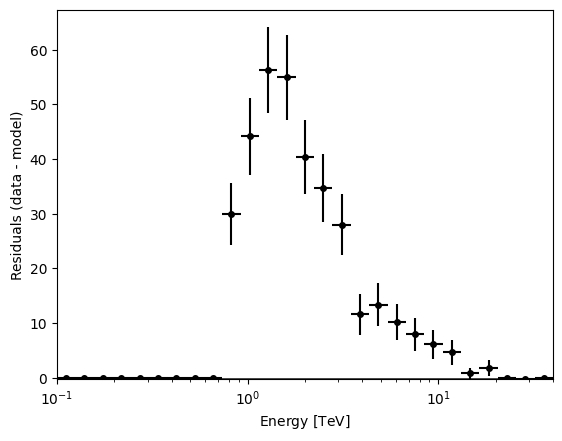

In [22]:
stacked.plot_residuals_spectral();

As expected for the Crab Nebula, the residuals show a clear positive excess when no source model is included. This indicates that the no-source hypothesis is not an adequate description of the data.

### H1: power-law source model

We now add a gamma-ray source model for the Crab Nebula. As a first spectral hypothesis, we use a simple power-law model.

This model describes the differential flux as a normalization at a reference energy multiplied by a power-law dependence on energy.

In [23]:
pl = PowerLawSpectralModel(
    amplitude=1e-11 * u.Unit("cm-2 s-1 TeV-1"),
    reference=1 * u.TeV,
    index=2.4,
)

model_pl = SkyModel(
    spectral_model=pl,
    name="crab_pl",
)

Before fitting, we inspect the model parameters. The table shows the initial values, units, allowed ranges, and whether each parameter is frozen or free during the fit.

In [24]:
model_pl.parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,index,2.4000e+00,,0.000e+00,nan,nan,False,,
,amplitude,1.0000e-11,cm-2 s-1 TeV-1,0.000e+00,nan,nan,False,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,


We now assign the power-law source model to the stacked dataset.

In [25]:
stacked.models = [model_pl]

stacked.models

And run the fit

In [26]:
# Fit the power-law model
stacked.models = model_pl

fit = Fit()
fit_result_h1 = fit.run([stacked])

print(fit_result_h1)

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 80
	total stat : 19.98

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



The fit summary reports whether the optimizer converged successfully and gives the final value of the fit statistic. The fitted parameter values can be inspected from the model parameter table below.

In [27]:
model_pl.parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,index,2.7231e+00,,8.285e-02,nan,nan,False,,
,amplitude,4.7043e-11,cm-2 s-1 TeV-1,3.429e-12,nan,nan,False,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,


For source detection in gamma-ray astronomy, it is common to define a test statistic

$
TS_{\rm src} = \mathrm{stat}(H0) - \mathrm{stat}(H1),
$

where H0 is the no-source hypothesis and H1 includes a source model. When the test is effectively driven by one additional source-amplitude parameter, a common approximation is

$
\sigma \simeq \sqrt{TS_{\rm src}}.
$

We use this convention here as an approximate detection significance.

In [28]:
stat_h1 = fit_result_h1.total_stat
ts_src = stat_h0 - stat_h1
sigma_src = np.sqrt(ts_src)

print(f"stat(H0) = {stat_h0:.2f}")
print(f"stat(H1) = {stat_h1:.2f}")
print(f"TS_src = stat(H0) - stat(H1) = {ts_src:.2f}")
print(f"Approximate detection significance = {sigma_src:.2f} sigma")

stat(H0) = 1259.57
stat(H1) = 19.98
TS_src = stat(H0) - stat(H1) = 1239.58
Approximate detection significance = 35.21 sigma


The fit statistic decreases dramatically when the Crab source model is included: from `stat(H0) = 1259.57` to `stat(H1) = 19.98`.

This gives $TS_{\rm src} \simeq 1240$, corresponding to an approximate detection significance of about $35\sigma$ using the common $\sqrt{TS}$ convention. This very large value is expected, since the Crab Nebula is a bright standard candle in very-high-energy gamma-ray astronomy.

The result should be interpreted as a clear diagnostic that the no-source hypothesis is inadequate for these data.

We can now inspect the fitted spectrum and residuals after adding the power-law source model.

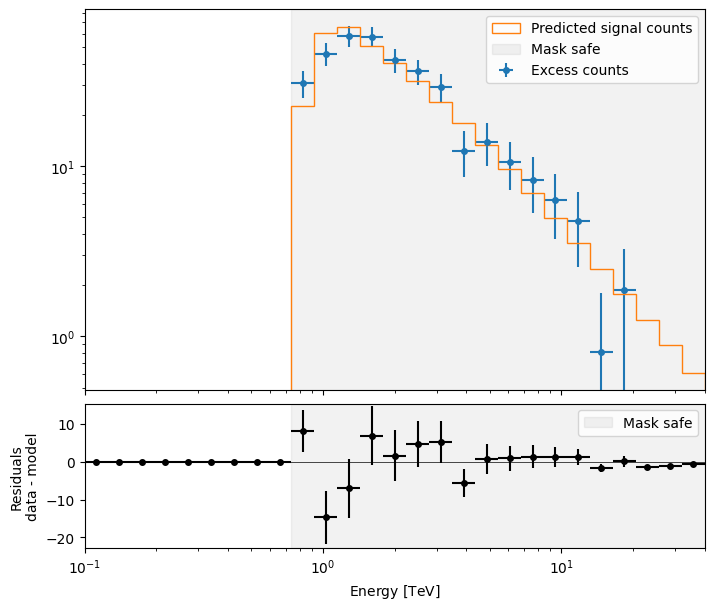

In [29]:
# Plot the fitted spectrum and residuals
ax_spectrum, ax_residuals = stacked.plot_fit()

After adding the source model, the residuals are much smaller than in the no-source case. This indicates that a simple power-law model already provides a reasonable first description of the Crab spectrum in this dataset.

We can also estimate flux points for the fitted power-law model.

Flux points provide a binned representation of the measured spectrum. They are useful for visualizing the spectral energy distribution and comparing the data with the fitted model.

In [30]:
# Energy bin edges used for the flux-point estimation
energy_edges = np.logspace(-1, 1.5, 12) * u.TeV

flux_points_estimator = FluxPointsEstimator(
    energy_edges=energy_edges,
    source="crab_pl",
    selection_optional=["ul"],
)

flux_points = flux_points_estimator.run(datasets=[stacked])

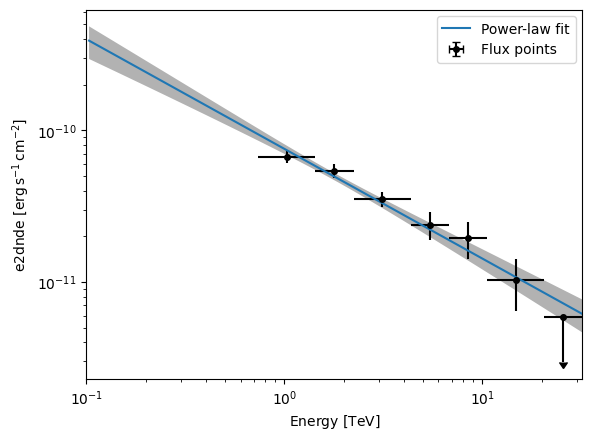

In [31]:
# Plot the fitted power-law model, error band, and flux points
ax = flux_points.plot(
    sed_type="e2dnde",
    label="Flux points",
    color = "black",
)

model_pl.spectral_model.plot(
    ax=ax,
    energy_bounds=(0.1 * u.TeV, 40 * u.TeV),
    sed_type="e2dnde",
    label="Power-law fit",
)

model_pl.spectral_model.plot_error(
    ax=ax,
    energy_bounds=(0.1 * u.TeV, 40 * u.TeV),
    sed_type="e2dnde",
    alpha=0.3,
)

ax.legend();

### H2: exponential-cutoff power-law source model

We now test a more flexible spectral model: a power law with an exponential cutoff.

This model can describe spectral curvature at high energies, which is often relevant for very-high-energy gamma-ray spectra. We will fit this model and compare its fit statistic with the simple power-law case.

In [32]:
# Define the exponential-cutoff power-law model
ecpl = ExpCutoffPowerLawSpectralModel(
    amplitude=model_pl.spectral_model.amplitude.quantity,
    reference=1 * u.TeV,
    index=model_pl.spectral_model.index.value,
    lambda_=0.1 / u.TeV,
)

model_ecpl = SkyModel(
    spectral_model=ecpl,
    name="crab_ecpl",
)

The cutoff is parametrized through `lambda_`, with characteristic cutoff energy $E_{\rm cut} = 1/\lambda$. Smaller values of `lambda_` correspond to higher cutoff energies.

In [33]:
model_ecpl.parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,index,2.7231e+00,,0.000e+00,nan,nan,False,,
,amplitude,4.7043e-11,cm-2 s-1 TeV-1,0.000e+00,nan,nan,False,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,
,lambda_,1.0000e-01,TeV-1,0.000e+00,nan,nan,False,,
,alpha,1.0000e+00,,0.000e+00,nan,nan,True,,


We now assign the ECPL source model to the stacked dataset.

In [34]:
stacked.models = [model_ecpl]

stacked.models

And run the fit

In [35]:
# Fit the exponential-cutoff power-law model
stacked.models = model_ecpl

fit_result_h2 = fit.run([stacked])

print(fit_result_h2)

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 82
	total stat : 16.57

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



In [36]:
model_ecpl.parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,index,2.4214e+00,,1.969e-01,nan,nan,False,,
,amplitude,4.8185e-11,cm-2 s-1 TeV-1,3.859e-12,nan,nan,False,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,
,lambda_,8.2184e-02,TeV-1,5.255e-02,nan,nan,False,,
,alpha,1.0000e+00,,0.000e+00,nan,nan,True,,


We now compare the exponential-cutoff power law against the simple power law.

Here we define

$
TS_{\rm cut} = \mathrm{stat}(H1) - \mathrm{stat}(H2).
$

A positive value means that the cutoff model improves the fit relative to the simple power-law model.

In [37]:
stat_h2 = fit_result_h2.total_stat
ts_cut = stat_h1 - stat_h2

print(f"stat(H1) = {stat_h1:.2f}")
print(f"stat(H2) = {stat_h2:.2f}")
print(f"TS_cut = stat(H1) - stat(H2) = {ts_cut:.2f}")

stat(H1) = 19.98
stat(H2) = 16.57
TS_cut = stat(H1) - stat(H2) = 3.41


If we interpret $TS_{\rm cut}$ approximately as a one-parameter likelihood-ratio test, the preference for the cutoff model can be estimated as

$
\sigma_{\rm cut} \simeq \sqrt{TS_{\rm cut}}.
$

This approximation treats the cutoff model as adding one effective degree of freedom relative to the simple power law.

In [38]:
sigma_cut = np.sqrt(ts_cut)

print(f"TS_cut = {ts_cut:.2f}")
print(f"Approximate preference for cutoff = {sigma_cut:.2f} sigma")

TS_cut = 3.41
Approximate preference for cutoff = 1.85 sigma


In [39]:
energy_edges = np.logspace(-1, 1.5, 12) * u.TeV  # 0.1–16 TeV
fpe = FluxPointsEstimator(energy_edges=energy_edges, source="crab_ecpl", selection_optional=["ul"])
flux_points = fpe.run(datasets=[stacked])

The cutoff model improves the fit statistic by $TS_{\rm cut}=3.41$, corresponding to an approximate preference of only $1.85\sigma$ if interpreted as a one-parameter likelihood-ratio test.

This is below the usual threshold for a significant detection or strong model preference. Therefore, the cutoff should not be interpreted as statistically superior to the simple power-law model,

In [40]:
# Estimate flux points using the ECPL model as reference
flux_points_estimator_h2 = FluxPointsEstimator(
    energy_edges=energy_edges,
    source="crab_ecpl",
    selection_optional=["ul"],
)

flux_points_h2 = flux_points_estimator_h2.run(datasets=[stacked])

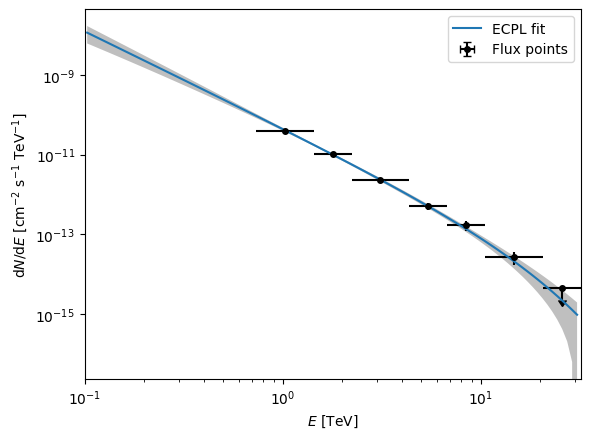

In [41]:
# Plot the ECPL fit with its error band and flux points
emin, emax = energy_edges[0], energy_edges[-1]

ax = flux_points_h2.plot(
    sed_type="dnde",
    marker="o",
    label="Flux points",
    color="black",
)

model_ecpl.spectral_model.plot(
    energy_bounds=(emin, emax),
    ax=ax,
    sed_type="dnde",
    label="ECPL fit",
)

model_ecpl.spectral_model.plot_error(
    energy_bounds=(emin, emax),
    ax=ax,
    sed_type="dnde",
    alpha=0.25,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$E$ [TeV]")
ax.set_ylabel(r"$\mathrm{d}N/\mathrm{d}E$ [cm$^{-2}$ s$^{-1}$ TeV$^{-1}$]")
ax.legend();

## Exercises

To explore the workflow further, try the following exercises:

- Test other spectral models, such as a log-parabola or a broken power law. See the Gammapy v1.3 model gallery for available spectral models: https://docs.gammapy.org/1.3/user-guide/model-gallery/spectral/index.html
- Select and analyze observations of another source in the public H.E.S.S. dataset, such as PKS 2155-304.
- Repeat the analysis using a joint fit of the individual observations instead of stacking them.
- Change the energy binning or safe-mask criteria and check how the fitted parameters and flux points change.